In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2021, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #684: 1480
Sim #1144: 1470
Sim #4271: 1430
Sim #2420: 1430
Sim #2736: 1420

BOTTOM 5 SCORES
Sim #6557: 180
Sim #4191: 190
Sim #1485: 190
Sim #7365: 190
Sim #5103: 190

AVERAGE SCORE: 550.85


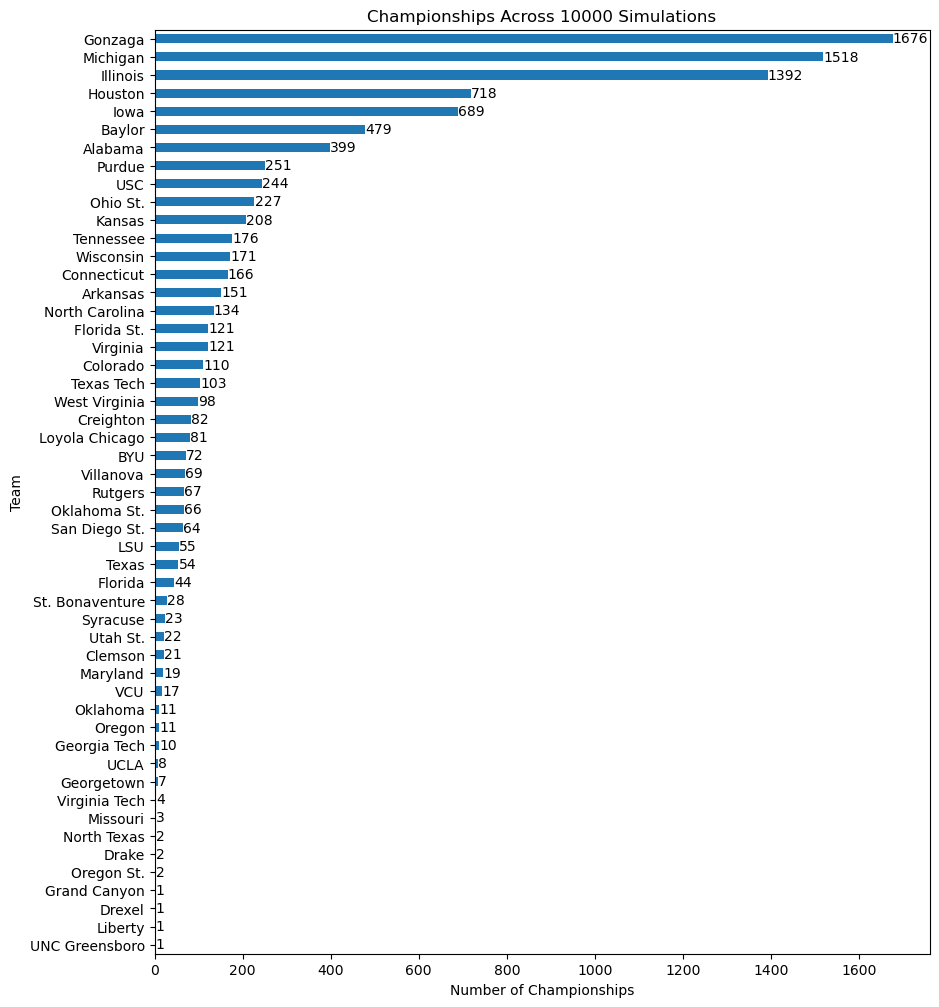

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Gonzaga           1676 --> 16.76%          BYU                72 --> 0.72%            North Texas         2 --> 0.02%         
Michigan          1518 --> 15.18%          Villanova          69 --> 0.69%            Liberty             1 --> 0.01%         
Illinois          1392 --> 13.92%          Rutgers            67 --> 0.67%            UNC Greensboro      1 --> 0.01%         
Houston           718 --> 7.18%            Oklahoma St.       66 --> 0.66%            Grand Canyon        1 --> 0.01%         
Iowa              689 --> 6.89%            San Diego St.      64 --> 0.64%            Drexel              1 --> 0.01%         
Baylor            479 --> 4.79%            LSU                55 --> 0.55%            Winthrop            0 --> 0.0%          
Alabama           399 --> 3.99%            Texas              54 --> 0.54%            UC Santa Barbara    0 --> 0.0%          
Purdue            251 --> 2.51%            Florida            44 -

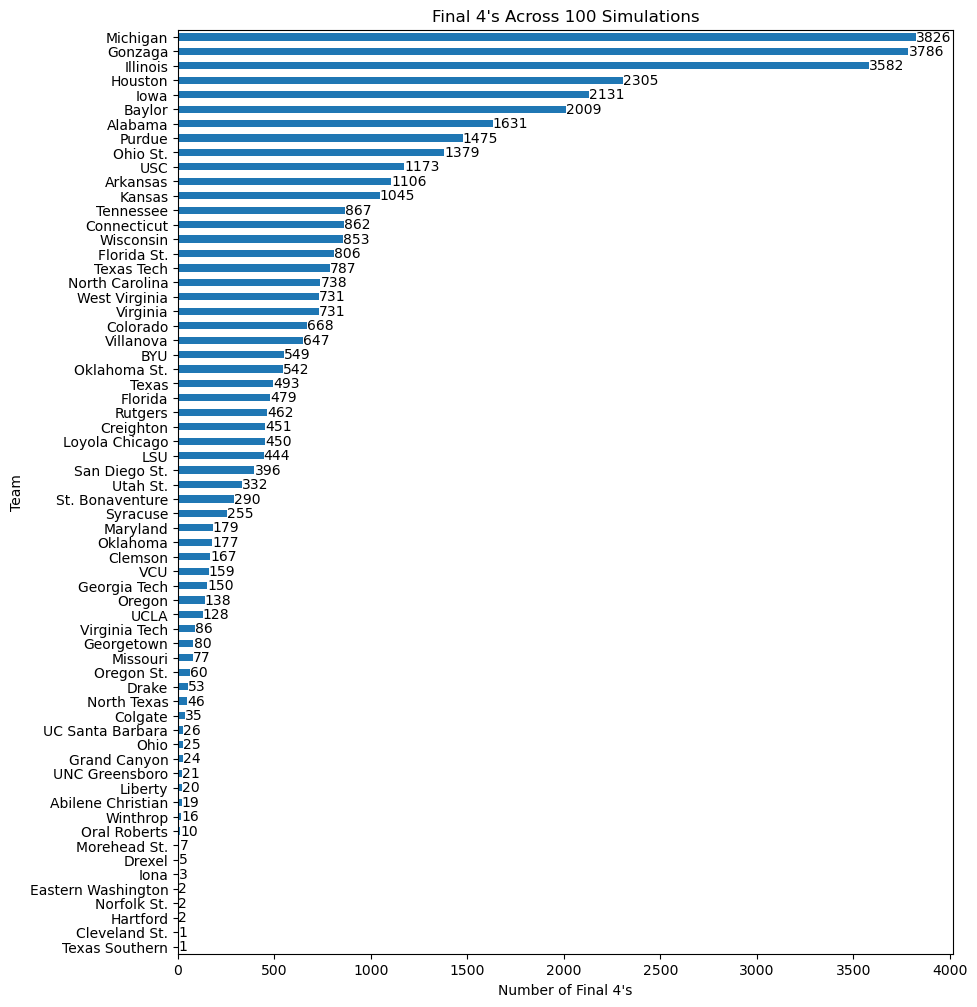

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Michigan          3826 --> 38.26%          Oklahoma St.      542 --> 5.42%            North Texas        46 --> 0.46%         
Gonzaga           3786 --> 37.86%          Texas             493 --> 4.93%            Colgate            35 --> 0.35%         
Illinois          3582 --> 35.82%          Florida           479 --> 4.79%            UC Santa Barbara   26 --> 0.26%         
Houston           2305 --> 23.05%          Rutgers           462 --> 4.62%            Ohio               25 --> 0.25%         
Iowa              2131 --> 21.31%          Creighton         451 --> 4.51%            Grand Canyon       24 --> 0.24%         
Baylor            2009 --> 20.09%          Loyola Chicago    450 --> 4.5%             UNC Greensboro     21 --> 0.21%         
Alabama           1631 --> 16.31%          LSU               444 --> 4.44%            Liberty            20 --> 0.2%          
Purdue            1475 --> 14.75%          San Diego St.     396 --> 3

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Gonzaga           5835 --> 58.35%          Oklahoma St.      1303 --> 13.03%          North Texas       168 --> 1.68%         
Illinois          5117 --> 51.17%          Florida           1297 --> 12.97%          Colgate           168 --> 1.68%         
Michigan          5094 --> 50.94%          Villanova         1296 --> 12.96%          Ohio              129 --> 1.29%         
Houston           4363 --> 43.63%          Rutgers           1265 --> 12.65%          Abilene Christian 120 --> 1.2%          
Iowa              3889 --> 38.89%          Creighton         1213 --> 12.13%          Grand Canyon      119 --> 1.19%         
Alabama           3451 --> 34.51%          Loyola Chicago    1050 --> 10.5%           UC Santa Barbara  105 --> 1.05%         
Baylor            3040 --> 30.4%           San Diego St.     1049 --> 10.49%          UNC Greensboro     97 --> 0.97%         
Ohio St.          2948 --> 29.48%          LSU               976 --> 9

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Gonzaga           7368 --> 73.68%          Villanova         3239 --> 32.39%          North Texas       707 --> 7.07%         
Illinois          6723 --> 67.23%          Connecticut       3220 --> 32.2%           Ohio              707 --> 7.07%         
Michigan          6578 --> 65.78%          Wisconsin         2742 --> 27.42%          Grand Canyon      673 --> 6.73%         
Iowa              6151 --> 61.51%          San Diego St.     2570 --> 25.7%           Abilene Christian 667 --> 6.67%         
Houston           5916 --> 59.16%          Rutgers           2488 --> 24.88%          UC Santa Barbara  635 --> 6.35%         
Purdue            5584 --> 55.84%          North Carolina    2415 --> 24.15%          Colgate           623 --> 6.23%         
Ohio St.          5429 --> 54.29%          LSU               2169 --> 21.69%          Liberty           575 --> 5.75%         
Alabama           5316 --> 53.16%          Syracuse          2118 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
385410,6023,1,Drexel,16,0,6,100.0,N/A,10.807,Illinois,19.625,Loyola Chicago,17.004,Tennessee,19.459,San Diego St.,18.981,Wisconsin,15.259,Alabama,0.002
439622,6870,1,Liberty,13,0,6,100.0,N/A,22.434,Oklahoma St.,35.270,Oregon St.,13.118,Illinois,22.188,San Diego St.,17.285,Arkansas,10.272,Gonzaga,0.004
456111,7127,3,UNC Greensboro,13,0,6,100.0,N/A,19.822,Florida St.,20.968,Colorado,19.098,St. Bonaventure,15.544,Connecticut,13.372,USC,29.619,Villanova,0.005
36338,568,4,Eastern Washington,14,0,5,100.0,N/A,16.582,Kansas,13.299,USC,17.815,Oregon,10.049,Gonzaga,15.785,Alabama,12.333,Illinois,0.005
161374,2522,2,Winthrop,12,0,5,100.0,N/A,22.309,Villanova,15.825,Purdue,13.919,Baylor,14.089,Arkansas,12.665,Illinois,28.167,LSU,0.006
301000,4704,1,Morehead St.,14,0,5,100.0,N/A,19.490,West Virginia,23.120,Syracuse,13.391,Houston,10.869,Illinois,12.190,Arkansas,14.831,Iowa,0.007
11798,185,2,North Texas,13,1,6,100.0,N/A,16.853,Purdue,34.819,Villanova,19.089,Wisconsin,28.490,Florida,19.700,Houston,15.387,Alabama,0.010
316980,4953,4,Grand Canyon,15,0,6,100.0,N/A,20.014,Iowa,30.977,VCU,13.309,USC,28.961,Oklahoma,18.003,Alabama,26.353,Rutgers,0.011
627805,9810,2,Virginia Tech,10,0,6,100.0,N/A,31.810,Florida,31.733,Ohio St.,22.546,Arkansas,21.520,Purdue,12.501,Illinois,21.613,Connecticut,0.013
404758,6325,2,North Texas,13,1,6,100.0,N/A,16.853,Purdue,34.819,Villanova,19.956,Baylor,28.490,Florida,26.198,Oklahoma St.,15.204,USC,0.013


In [11]:
df[df["sim_num"] == 684].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
43729,684,2,Baylor,1,6,6,100.0,N/A,85.846,Hartford,53.099,North Carolina,69.090,Villanova,72.218,Florida,46.825,Houston,36.761,Gonzaga,3.915
43763,684,4,Gonzaga,1,5,5,100.0,N/A,90.732,Norfolk St.,83.344,Missouri,80.824,Creighton,64.383,USC,75.544,Florida St.,63.239,Baylor,10.928
43749,684,3,Florida St.,4,2,4,100.0,N/A,80.178,UNC Greensboro,49.517,Colorado,48.884,St. Bonaventure,54.938,BYU,24.456,Gonzaga,0.000,N/A,8.055
43716,684,1,Houston,2,4,4,100.0,N/A,88.310,Cleveland St.,71.364,Clemson,73.005,West Virginia,63.759,Loyola Chicago,53.175,Baylor,0.000,N/A,13.736
43773,684,4,USC,6,3,3,100.0,N/A,78.592,Drake,54.380,Kansas,41.059,Iowa,35.617,Gonzaga,0.000,N/A,0.000,N/A,11.298
43746,684,3,BYU,6,0,3,100.0,N/A,64.854,UCLA,49.342,Texas,38.464,Alabama,45.062,Florida St.,0.000,N/A,0.000,N/A,6.762
43731,684,2,Florida,7,1,3,100.0,N/A,68.190,Virginia Tech,85.800,Oral Roberts,34.404,Texas Tech,27.782,Baylor,0.000,N/A,0.000,N/A,14.537
43719,684,1,Loyola Chicago,8,2,3,100.0,N/A,59.031,Georgia Tech,27.478,Illinois,64.709,Oregon St.,36.241,Houston,0.000,N/A,0.000,N/A,6.692
43738,684,2,Texas Tech,6,1,2,100.0,N/A,60.720,Utah St.,48.853,Arkansas,65.596,Florida,0.000,N/A,0.000,N/A,0.000,N/A,10.205
43727,684,1,West Virginia,3,1,2,100.0,N/A,80.510,Morehead St.,64.011,Syracuse,26.995,Houston,0.000,N/A,0.000,N/A,0.000,N/A,37.623


In [12]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  252


In [14]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  4
[1443 4671 8263 9063]


In [25]:
df[df["sim_num"] == 8263].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
528819,8263,4,Gonzaga,1,5,6,100.0,N/A,90.732,Norfolk St.,83.344,Missouri,80.824,Creighton,64.383,USC,82.767,UCLA,63.239,Baylor,20.596
528785,8263,2,Baylor,1,6,5,100.0,N/A,85.846,Hartford,54.759,Wisconsin,69.090,Villanova,61.694,Utah St.,46.825,Houston,36.761,Gonzaga,5.933
528814,8263,3,UCLA,11,4,4,100.0,N/A,35.146,BYU,36.475,Texas,31.117,Alabama,27.421,Florida St.,17.233,Gonzaga,0.000,N/A,0.905
528772,8263,1,Houston,2,4,4,100.0,N/A,88.310,Cleveland St.,71.364,Clemson,73.005,West Virginia,80.552,Oregon St.,53.175,Baylor,0.000,N/A,17.354
528795,8263,2,Utah St.,11,0,3,100.0,N/A,39.280,Texas Tech,36.869,Arkansas,49.006,Ohio St.,38.306,Baylor,0.000,N/A,0.000,N/A,4.378
528829,8263,4,USC,6,3,3,100.0,N/A,78.592,Drake,54.380,Kansas,41.059,Iowa,35.617,Gonzaga,0.000,N/A,0.000,N/A,11.298
528805,8263,3,Florida St.,4,2,3,100.0,N/A,80.178,UNC Greensboro,70.304,Georgetown,25.054,Michigan,72.579,UCLA,0.000,N/A,0.000,N/A,3.873
528778,8263,1,Oregon St.,12,3,3,100.0,N/A,29.222,Tennessee,64.730,Liberty,35.291,Loyola Chicago,19.448,Houston,0.000,N/A,0.000,N/A,5.377
528791,8263,2,Ohio St.,2,0,2,100.0,N/A,88.076,Oral Roberts,57.404,Florida,50.994,Utah St.,0.000,N/A,0.000,N/A,0.000,N/A,24.777
528801,8263,3,Alabama,2,2,2,100.0,N/A,87.709,Iona,53.066,Connecticut,68.883,UCLA,0.000,N/A,0.000,N/A,0.000,N/A,14.483


In [26]:
scores[8262]

1310

In [27]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [28]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [29]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [31]:
df[(df["TEAM"] == "UCLA") & (df["R32_opp"] == "Abilene Christian") & (df["S16_opp"] == "Alabama") & (df["E8_opp"] == "Michigan") & (df["F4_opp"] == "Gonzaga")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
92334,1443,3,UCLA,11,4,4,100.0,N/A,35.146,BYU,60.542,Abilene Christian,31.117,Alabama,16.283,Michigan,17.233,Gonzaga,0.0,N/A,0.892
129838,2029,3,UCLA,11,4,4,100.0,N/A,35.146,BYU,60.542,Abilene Christian,31.117,Alabama,16.283,Michigan,17.233,Gonzaga,0.0,N/A,0.892


In [34]:
df[df["sim_num"] == 1443].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
92292,1443,1,Houston,2,4,6,100.0,N/A,88.310,Cleveland St.,71.364,Clemson,73.005,West Virginia,40.010,Illinois,53.175,Baylor,32.069,Gonzaga,3.139
92339,1443,4,Gonzaga,1,5,5,100.0,N/A,90.732,Norfolk St.,80.184,Oklahoma,74.208,Virginia,64.383,USC,82.767,UCLA,67.931,Houston,9.226
92305,1443,2,Baylor,1,6,4,100.0,N/A,85.846,Hartford,54.759,Wisconsin,60.736,Purdue,66.319,Texas Tech,46.825,Houston,0.000,N/A,10.069
92334,1443,3,UCLA,11,4,4,100.0,N/A,35.146,BYU,60.542,Abilene Christian,31.117,Alabama,16.283,Michigan,17.233,Gonzaga,0.000,N/A,0.892
92314,1443,2,Texas Tech,6,1,3,100.0,N/A,60.720,Utah St.,48.853,Arkansas,43.827,Ohio St.,33.681,Baylor,0.000,N/A,0.000,N/A,8.622
92330,1443,3,Michigan,1,3,3,100.0,N/A,89.960,Texas Southern,81.642,St. Bonaventure,74.535,Colorado,83.717,UCLA,0.000,N/A,0.000,N/A,8.914
92349,1443,4,USC,6,3,3,100.0,N/A,78.592,Drake,86.701,Eastern Washington,78.313,VCU,35.617,Gonzaga,0.000,N/A,0.000,N/A,34.357
92293,1443,1,Illinois,1,1,3,100.0,N/A,89.193,Drexel,72.522,Loyola Chicago,71.410,Tennessee,59.990,Houston,0.000,N/A,0.000,N/A,18.481
92311,1443,2,Ohio St.,2,0,2,100.0,N/A,88.076,Oral Roberts,57.404,Florida,56.173,Texas Tech,0.000,N/A,0.000,N/A,0.000,N/A,22.159
92321,1443,3,Alabama,2,2,2,100.0,N/A,87.709,Iona,73.029,Maryland,68.883,UCLA,0.000,N/A,0.000,N/A,0.000,N/A,19.931


In [35]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
431402,6741,3,Michigan,1,3,6,100.0,N/A,89.960,Texas Southern,81.642,St. Bonaventure,74.946,Florida St.,66.843,Alabama,70.978,Kansas,68.202,Ohio St.,17.811
431383,6741,2,Ohio St.,2,0,5,100.0,N/A,88.076,Oral Roberts,57.404,Florida,51.874,Arkansas,47.456,Purdue,59.123,West Virginia,31.798,Michigan,5.019
431375,6741,1,West Virginia,3,1,4,100.0,N/A,80.510,Morehead St.,56.358,San Diego St.,57.387,Clemson,49.656,Oklahoma St.,40.877,Ohio St.,0.000,N/A,7.645
431414,6741,4,Kansas,3,1,4,100.0,N/A,83.418,Eastern Washington,68.970,Drake,38.922,Iowa,37.974,Gonzaga,29.022,Michigan,0.000,N/A,6.036
431393,6741,3,Alabama,2,2,3,100.0,N/A,87.709,Iona,73.029,Maryland,63.854,Texas,33.157,Michigan,0.000,N/A,0.000,N/A,27.339
431385,6741,2,Purdue,4,0,3,100.0,N/A,83.147,North Texas,84.175,Winthrop,48.879,North Carolina,52.544,Ohio St.,0.000,N/A,0.000,N/A,16.234
431411,6741,4,Gonzaga,1,5,3,100.0,N/A,90.732,Norfolk St.,80.184,Oklahoma,80.824,Creighton,62.026,Kansas,0.000,N/A,0.000,N/A,22.329
431369,6741,1,Oklahoma St.,4,1,3,100.0,N/A,77.566,Liberty,41.679,Tennessee,47.812,Loyola Chicago,50.344,West Virginia,0.000,N/A,0.000,N/A,7.675
431404,6741,3,Texas,3,0,2,100.0,N/A,75.396,Abilene Christian,63.525,UCLA,36.146,Alabama,0.000,N/A,0.000,N/A,0.000,N/A,30.583
431397,6741,3,Florida St.,4,2,2,100.0,N/A,80.178,UNC Greensboro,49.517,Colorado,25.054,Michigan,0.000,N/A,0.000,N/A,0.000,N/A,29.755


In [39]:
df[(df["TEAM"] == "Wisconsin") & (df["E8_opp"] == "Oral Roberts")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
31775,497,2,Wisconsin,9,1,4,100.0,N/A,54.177,North Carolina,45.241,Baylor,55.108,Villanova,83.403,Oral Roberts,41.761,Houston,0.000,N/A,6.561
98783,1544,2,Wisconsin,9,1,3,100.0,N/A,54.177,North Carolina,45.241,Baylor,49.636,Purdue,83.403,Oral Roberts,0.000,N/A,0.000,N/A,2.019
271327,4240,2,Wisconsin,9,1,5,100.0,N/A,54.177,North Carolina,45.241,Baylor,55.108,Villanova,83.403,Oral Roberts,41.761,Houston,37.726,Iowa,2.930
333599,5213,2,Wisconsin,9,1,5,100.0,N/A,54.177,North Carolina,45.241,Baylor,83.543,Winthrop,83.403,Oral Roberts,32.605,Illinois,28.098,Michigan,4.004


In [40]:
df.to_csv("../../data/2021_10000sims0.csv")